In [77]:
import os
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt

In [78]:
RESULTS_DIR = 'results/mnist_ae_grid_log_bottleneck'

results = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, 'result_*.pkl'))):
    with open(path, 'rb') as f:
        results.append(pickle.load(f))

print(f'Loaded {len(results)} result(s)')
print('Keys:', list(results[0].keys()) if results else 'none')

Loaded 240 result(s)
Keys: ['n_b', 'n_d', 'm', 'seeds', 'model_name', 'recon_train_mean', 'recon_train_std', 'recon_test_mean', 'recon_test_std', 'train_error_mean', 'train_error_std', 'gen_error_mean', 'gen_error_std', 'crossentropy_test_mean', 'crossentropy_test_std', 'crossentropy_train_mean', 'crossentropy_train_std', 'probe_losses', 'ae_train_losses', 'ae_eval_losses']


## AE training loss trajectory

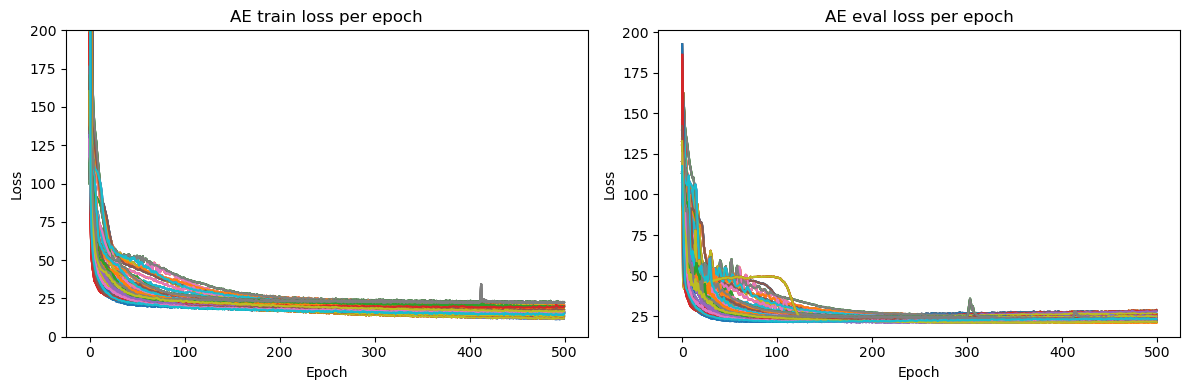

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in results:
    label = f"n_b={r['n_b']}, m={r['m']}"
    ae_train = r.get('ae_train_losses') or []
    ae_eval  = r.get('ae_eval_losses') or []

    if ae_train:
        axes[0].plot(ae_train, label=label)
    if ae_eval:
        axes[1].plot(ae_eval, label=label)

axes[0].set_title('AE train loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(0, 200)

axes[1].set_title('AE eval loss per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

## Linear probe loss trajectory

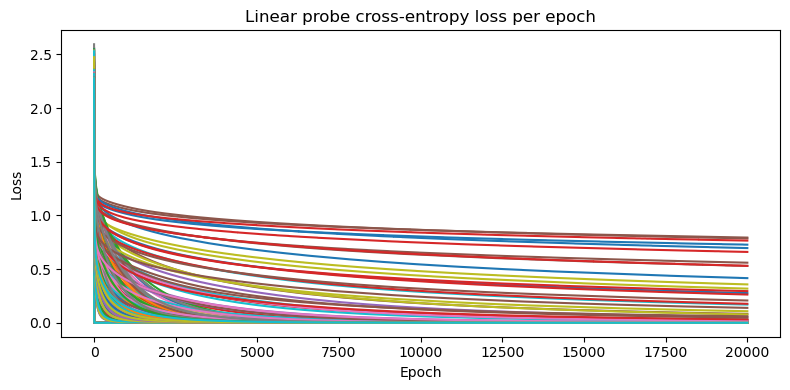

In [80]:
fig, ax = plt.subplots(figsize=(8, 4))

for r in results:
    if r.get('probe_losses'):
        label = f"n_b={r['n_b']}, n_d={r['n_d']}, m={r['m']}"
        ax.plot(r['probe_losses'], label=label)

ax.set_title('Linear probe cross-entropy loss per epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

## Optimal latent dimension m(n_b, n_d)

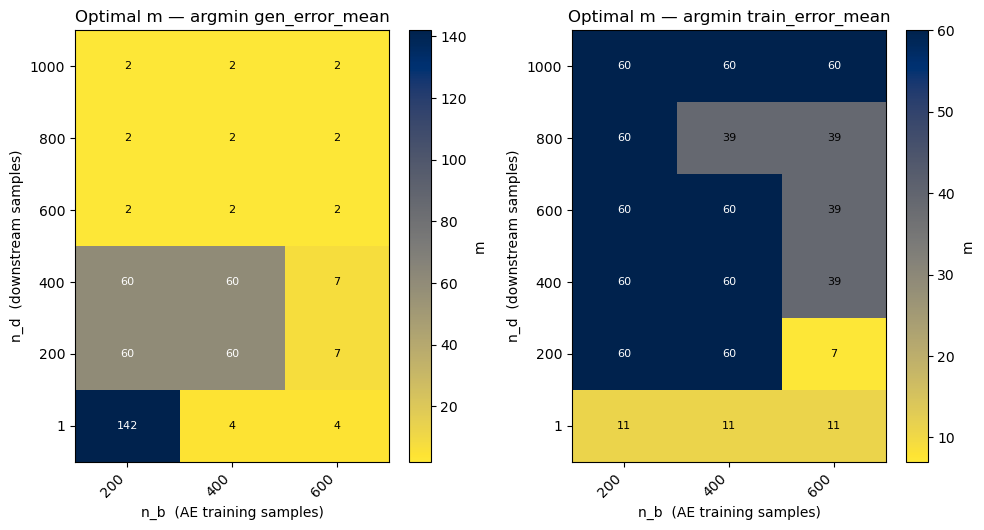

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

def optimal_m_grid(df, metric_mean):
    """Pivot of optimal m per (n_b, n_d), chosen by argmin of metric_mean."""
    idx_best  = df.groupby(['n_b', 'n_d'])[metric_mean].idxmin()
    best_m_df = df.loc[idx_best, ['n_b', 'n_d', 'm']]
    pivot     = best_m_df.pivot(index='n_d', columns='n_b', values='m').sort_index(ascending=True)
    return pivot

def plot_m_grid(ax, pivot, title):
    n_b_vals = pivot.columns.tolist()
    n_d_vals = pivot.index.tolist()
    im = ax.imshow(
        pivot.values, aspect='auto', origin='lower',
        extent=[-0.5, len(n_b_vals) - 0.5, -0.5, len(n_d_vals) - 0.5],
        cmap = 'cividis_r'
    )
    ax.set_xticks(range(len(n_b_vals)))
    ax.set_xticklabels(n_b_vals, rotation=45, ha='right')
    ax.set_yticks(range(len(n_d_vals)))
    ax.set_yticklabels(n_d_vals)
    ax.set_xlabel('n_b  (AE training samples)')
    ax.set_ylabel('n_d  (downstream samples)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='m')
    mean_val = np.nanmean(pivot.values)
    for i, nd in enumerate(n_d_vals):
        for j, nb in enumerate(n_b_vals):
            val = pivot.loc[nd, nb]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=8, color='white' if val > mean_val else 'black')

#pivot_gen   = optimal_m_grid(df, 'crossentropy_test_mean')
#pivot_train = optimal_m_grid(df, 'crossentropy_train_mean')
pivot_gen   = optimal_m_grid(df, 'gen_error_mean')
pivot_train = optimal_m_grid(df, 'train_error_mean')
fig, axes = plt.subplots(1, 2, figsize=(max(10, len(pivot_gen.columns) * 2.2),
                                        max(4, len(pivot_gen.index) * 0.9)))
plot_m_grid(axes[0], pivot_gen,   'Optimal m — argmin gen_error_mean')
plot_m_grid(axes[1], pivot_train, 'Optimal m — argmin train_error_mean')

plt.tight_layout()
plt.show()

## Error vs m for selected (n_b, n_d) pairs

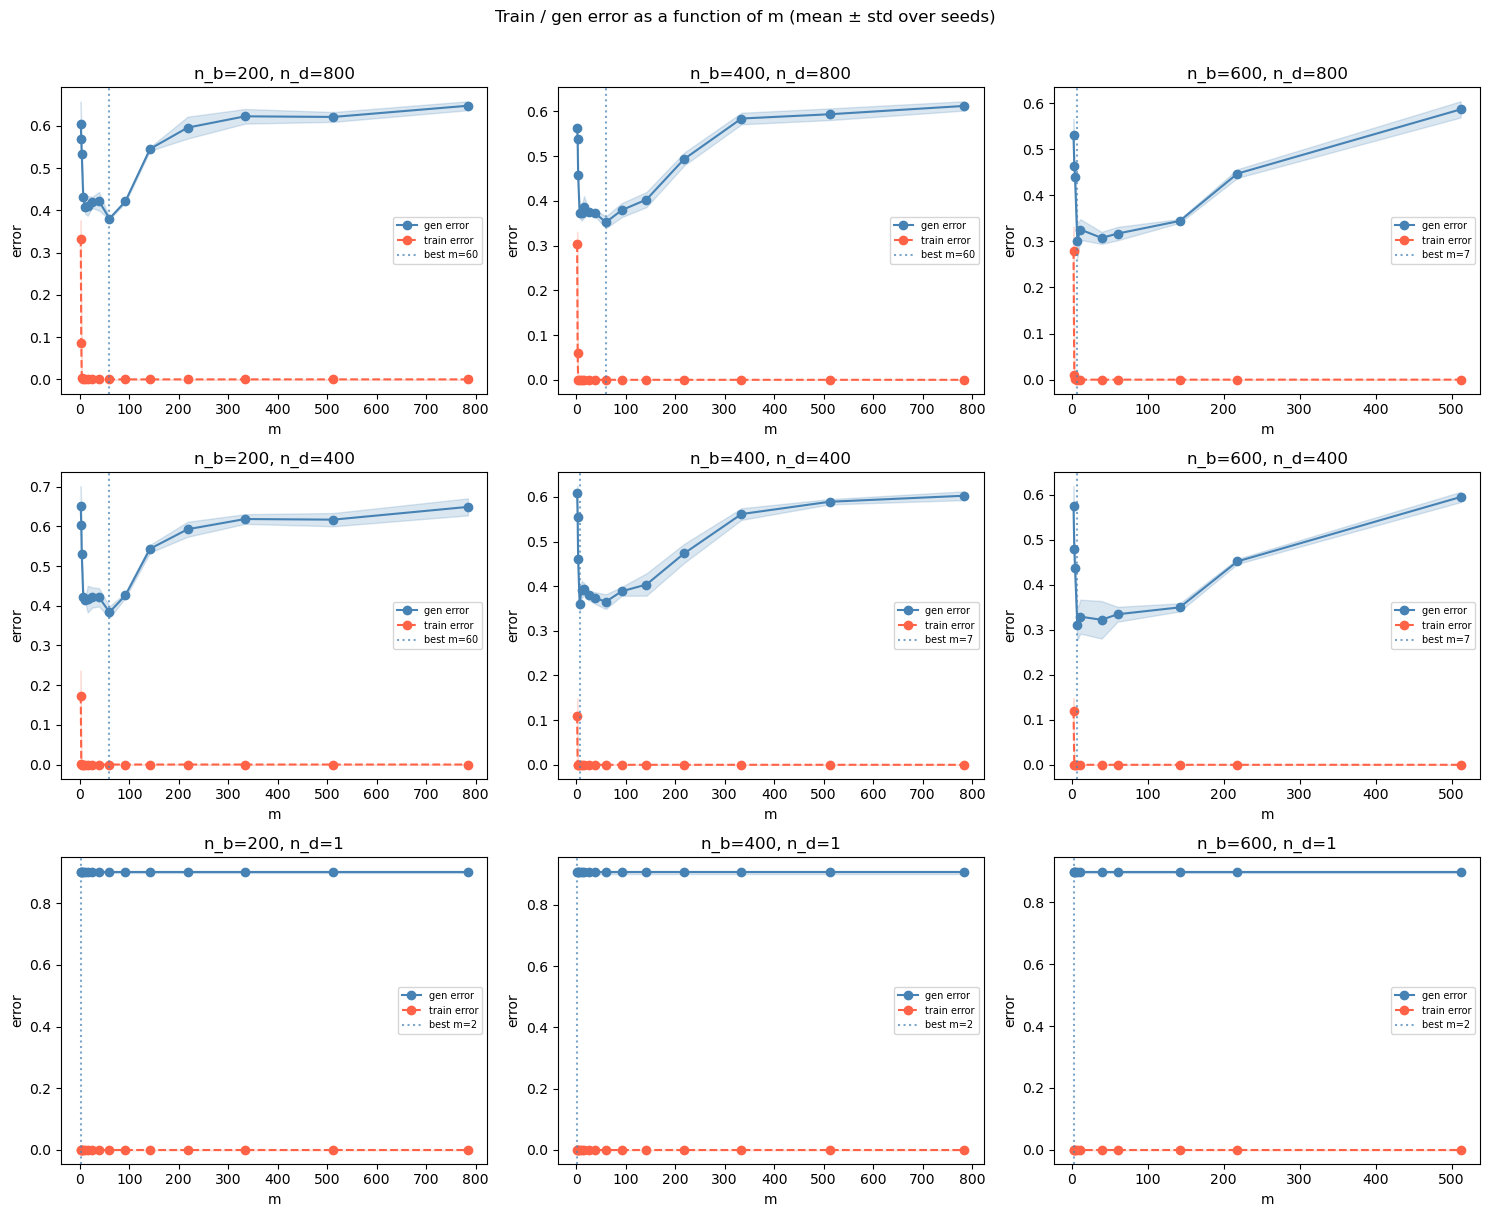

In [82]:
# Pick a representative sample of (n_b, n_d) pairs spread across the grid
all_nb = sorted(df['n_b'].unique())
all_nd = sorted(df['n_d'].unique())

sample_nb = all_nb[::max(1, len(all_nb) // 3)][:3]
sample_nd = all_nd[::max(1, len(all_nd) // 3)][:3]

fig, axes = plt.subplots(len(sample_nd), len(sample_nb),
                         figsize=(5 * len(sample_nb), 4 * len(sample_nd)),
                         sharey=False, squeeze=False)

for row, nd in enumerate(reversed(sample_nd)):
    for col, nb in enumerate(sample_nb):
        ax = axes[row][col]
        subset = df[(df['n_b'] == nb) & (df['n_d'] == nd)].sort_values('m')
        m_vals = subset['m'].values

        for metric, color, label, ls in [
            ('gen_error',   'steelblue', 'gen error',   '-'),
            ('train_error', 'tomato',    'train error', '--'),
        ]:
            mean = subset[f'{metric}_mean'].values
            std  = subset[f'{metric}_std'].fillna(0).values
            ax.plot(m_vals, mean, marker='o', color=color, label=label, linestyle=ls)
            ax.fill_between(m_vals, mean - std, mean + std, alpha=0.2, color=color)

        best_m = float(subset.loc[subset['gen_error_mean'].idxmin(), 'm'])
        ax.axvline(best_m, color='steelblue', linestyle=':', alpha=0.7, label=f'best m={best_m:.0f}')

        ax.set_title(f'n_b={nb}, n_d={nd}')
        ax.set_xlabel('m')
        ax.set_ylabel('error')
        ax.legend(fontsize=7)

plt.suptitle('Train / gen error as a function of m (mean ± std over seeds)', y=1.01)
plt.tight_layout()
plt.show()